# Cost Analysis Notebook

Simple analysis of the cost to run the cloud services for the IOT system. Estimate cost per 1000 users using a simple monte-carlo simulation to estimate user usage of resources.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch

np.random.seed(42)
os.makedirs("../data", exist_ok=True)

# ── AWS Pricing Constants (us-east-1, 2025) ───────────────────────────────────

# CloudFront
CF_DATA_TRANSFER_PER_GB = 0.0085  # $/GB out to internet (first 10 TB/mo)
CF_HTTPS_REQ_PER_10K = 0.0100  # $/10,000 HTTPS requests

# API Gateway (REST)
APIGW_PER_MILLION_CALLS = 3.50  # $/million REST API calls

# WAF
WAF_MONTHLY_FIXED = 5.00 + 5 * 1.00  # $5 web ACL + 5 rules @ $1 each
WAF_PER_MILLION_REQUESTS = 0.60  # $/million requests evaluated

# Cognito  (first 50 K MAUs free; 1 K users stays in free tier)
COGNITO_PER_MAU = 0.0055
COGNITO_FREE_TIER_MAUS = 50_000

# IoT Core
IOT_MSG_PER_MILLION = 1.00  # $/million messages
IOT_CONN_PER_MILLION_MIN = 0.042  # $/million device-connection-minutes

# IoT Device Management (fleet indexing)
IOT_DM_PER_THING_MONTH = 0.10  # $/registered thing/month

# Kinesis Video Streams
KVS_INGEST_PER_GB = 0.0085  # $/GB ingested
KVS_STORE_PER_GB_MONTH = 0.023  # $/GB stored/month
KVS_CONSUME_PER_GB = 0.0085  # $/GB consumed (live / playback)

# Lambda
LAMBDA_REQ_PER_MILLION = 0.20  # $/million invocations
LAMBDA_PER_GB_SEC = 0.0000166667  # $/GB-second compute duration

# Step Functions
SFN_PER_1K_TRANSITIONS = 0.025  # $/1,000 state transitions

# SNS
SNS_PUSH_PER_MILLION = 0.50  # $/million mobile-push notifications

# DynamoDB (on-demand capacity mode)
DYNAMO_RCU_PER_MILLION = 0.25  # $/million read request units
DYNAMO_WCU_PER_MILLION = 1.25  # $/million write request units
DYNAMO_STORAGE_PER_GB = 0.25  # $/GB/month

# Timestream (magnetic store)
TS_WRITE_PER_MILLION = 0.50  # $/million writes
TS_MAG_STORE_PER_GB = 0.03  # $/GB/month (magnetic tier)
TS_QUERY_PER_GB_SCANNED = 0.01  # $/GB scanned by queries

# S3
S3_STORAGE_PER_GB = 0.023  # $/GB/month (Standard)
S3_PUT_PER_1K = 0.005  # $/1,000 PUT/COPY/POST requests
S3_GET_PER_1K = 0.0004  # $/1,000 GET requests
S3_TRANSFER_OUT_PER_GB = 0.09  # $/GB data transfer out

# CloudWatch
CW_LOG_INGEST_PER_GB = 0.50  # $/GB logs ingested
CW_LOG_STORE_PER_GB = 0.03  # $/GB logs stored
CW_METRIC_PER_MONTH = 0.30  # $/custom metric/month
CW_ALARM_PER_MONTH = 0.10  # $/alarm/month

# ── Usage Distribution Parameters ────────────────────────────────────────────

N = 1_000  # simulated user population
DAYS = 30  # one billing month

# Usage intensity [0, 1] — scales all per-user activity levels
USAGE_MEAN, USAGE_STD = 0.50, 0.20

# Household devices (non-camera modules: lights, locks, thermostats, sensors)
MIN_DEVICES, MAX_DEVICES = 1, 12

# Camera adoption and configuration
CAMERA_PROBABILITY = 0.45  # 45 % of households have ≥1 camera
MAX_CAMERAS = 4
VIDEO_RETENTION_OPTIONS = [7, 14, 30, 90]
VIDEO_RETENTION_PROBS = [0.25, 0.40, 0.25, 0.10]

# API call range (low–high intensity, calls/day)
DAILY_API_LOW, DAILY_API_HIGH = 15, 250

# IoT telemetry messages per device per day
IOT_MSG_LOW, IOT_MSG_HIGH = 50, 600

# Camera recording hours per day (motion + scheduled)
CAM_ACTIVE_LOW, CAM_ACTIVE_HIGH = 2, 24  # hours

# Camera live-view / playback hours per day
CAM_VIEW_LOW, CAM_VIEW_HIGH = 0.1, 2.0  # hours

# Automation rules configured per user
AUTO_RULES_LOW, AUTO_RULES_HIGH = 0, 15

# Notification opt-in rate
NOTIFICATION_PROB = 0.70

print("Pricing constants and usage parameters loaded.")

Pricing constants and usage parameters loaded.


In [2]:
rng = np.random.default_rng(42)

# ── Sample per-user random variables ─────────────────────────────────────────

usage = np.clip(rng.normal(USAGE_MEAN, USAGE_STD, N), 0.05, 1.0)
num_devices = rng.integers(MIN_DEVICES, MAX_DEVICES + 1, N)
has_camera = rng.random(N) < CAMERA_PROBABILITY
num_cameras = np.where(has_camera, rng.integers(1, MAX_CAMERAS + 1, N), 0)
vid_ret_days = rng.choice(VIDEO_RETENTION_OPTIONS, size=N, p=VIDEO_RETENTION_PROBS)
notif_on = rng.random(N) < NOTIFICATION_PROB

daily_api = DAILY_API_LOW + usage * (DAILY_API_HIGH - DAILY_API_LOW)
iot_msg_per_dev = IOT_MSG_LOW + usage * (IOT_MSG_HIGH - IOT_MSG_LOW)
cam_active_hrs = CAM_ACTIVE_LOW + usage * (CAM_ACTIVE_HIGH - CAM_ACTIVE_LOW)
cam_view_hrs = CAM_VIEW_LOW + usage * (CAM_VIEW_HIGH - CAM_VIEW_LOW)
auto_rules = (AUTO_RULES_LOW + usage * (AUTO_RULES_HIGH - AUTO_RULES_LOW)).astype(int)

# ── Monthly aggregate volumes ─────────────────────────────────────────────────

monthly_api_calls = daily_api * DAYS
monthly_iot_msgs = iot_msg_per_dev * num_devices * DAYS

# KVS video volumes  (1080p ≈ 1.35 GB/hr)
kvs_ingest_gb = num_cameras * cam_active_hrs * DAYS * 1.35
kvs_view_gb = num_cameras * cam_view_hrs * DAYS * 1.35
kvs_storage_gb = kvs_ingest_gb * (vid_ret_days / 30)  # retained in Kinesis
s3_archive_gb = kvs_ingest_gb * 0.30 * (vid_ret_days / 30)  # 30 % archived to S3

# Lambda invocation count
lambda_invocations = (
    monthly_api_calls  # one function per API request
    + monthly_iot_msgs * 0.20  # 20 % of IoT messages trigger Lambda
    + auto_rules * 2 * DAYS  # ~2 rule evaluations/day each
)

# ── Per-service cost calculations ─────────────────────────────────────────────

# CloudFront — bandwidth (~2 MB avg response) + request fee
cf_data_gb = monthly_api_calls * 0.002 + 0.05  # 50 MB static frontend
cost_cf = (
    cf_data_gb * CF_DATA_TRANSFER_PER_GB
    + monthly_api_calls / 10_000 * CF_HTTPS_REQ_PER_10K
)

# API Gateway
cost_apigw = monthly_api_calls / 1e6 * APIGW_PER_MILLION_CALLS

# WAF — fixed overhead amortised across fleet, plus per-request variable
cost_waf = WAF_MONTHLY_FIXED / N + monthly_api_calls / 1e6 * WAF_PER_MILLION_REQUESTS

# Cognito — 1 K users well under 50 K MAU free tier
cost_cognito = np.zeros(N)

# IoT Core — messages + device-connection minutes
iot_conn_min = num_devices * 24 * 60 * DAYS  # 24/7 persistent connections
cost_iot = (
    monthly_iot_msgs / 1e6 * IOT_MSG_PER_MILLION
    + iot_conn_min / 1e6 * IOT_CONN_PER_MILLION_MIN
)

# IoT Device Management — fleet indexing per registered thing
cost_iot_dm = num_devices * IOT_DM_PER_THING_MONTH

# Kinesis Video Streams — compute: ingest + consume; storage handled separately
cost_kvs_c = kvs_ingest_gb * KVS_INGEST_PER_GB + kvs_view_gb * KVS_CONSUME_PER_GB
cost_kvs_s = kvs_storage_gb * KVS_STORE_PER_GB_MONTH

# Lambda — requests + compute duration (200 ms avg, 512 MB memory)
lambda_gb_s = lambda_invocations * 0.200 * 0.512
cost_lambda = (
    lambda_invocations / 1e6 * LAMBDA_REQ_PER_MILLION + lambda_gb_s * LAMBDA_PER_GB_SEC
)

# Step Functions — automation workflows (avg 5 transitions each, fires 2×/day)
sfn_trans = auto_rules * 2 * 5 * DAYS
cost_sfn = sfn_trans / 1_000 * SFN_PER_1K_TRANSITIONS

# SNS — mobile push: 5 % of IoT events become notifications (opt-in only)
sns_notifs = np.where(notif_on, monthly_iot_msgs * 0.05, 0.0)
cost_sns = sns_notifs / 1e6 * SNS_PUSH_PER_MILLION

# DynamoDB — 3 reads + 1.1 writes per API call; 10 % of IoT msgs update state
dynamo_reads = monthly_api_calls * 3
dynamo_write = monthly_api_calls + monthly_iot_msgs * 0.10
dynamo_stor = (num_devices * 5 + 500) / (1024**2)  # KB → GB (tiny)
cost_dynamo_c = (
    dynamo_reads / 1e6 * DYNAMO_RCU_PER_MILLION
    + dynamo_write / 1e6 * DYNAMO_WCU_PER_MILLION
)
cost_dynamo_s = dynamo_stor * DYNAMO_STORAGE_PER_GB

# Timestream — one write per IoT telemetry record; ~100 B each
ts_stor_gb = monthly_iot_msgs * 100e-9  # bytes → GB
cost_ts_c = monthly_iot_msgs / 1e6 * TS_WRITE_PER_MILLION
cost_ts_s = ts_stor_gb * TS_MAG_STORE_PER_GB

# S3 — frontend static assets (shared), camera archival, retrieval
s3_stor_gb = 0.05 / N + s3_archive_gb  # 50 MB frontend amortised
s3_puts = s3_archive_gb * 1024  # ~1 PUT per MB archived
s3_gets = monthly_api_calls * 0.05  # 5 % of requests touch S3
s3_xfer_gb = s3_archive_gb * 0.10  # 10 % recalled for playback
cost_s3_s = s3_stor_gb * S3_STORAGE_PER_GB
cost_s3_r = s3_puts / 1_000 * S3_PUT_PER_1K + s3_gets / 1_000 * S3_GET_PER_1K
cost_s3_x = s3_xfer_gb * S3_TRANSFER_OUT_PER_GB

# CloudWatch — log ingestion (~1 KB per Lambda invocation) + shared fixed metrics
cw_log_gb = lambda_invocations * 1e-6
cw_fixed = (20 * CW_METRIC_PER_MONTH + 10 * CW_ALARM_PER_MONTH) / N
cost_cw = cw_log_gb * CW_LOG_INGEST_PER_GB + cw_fixed

# ── Roll up into three high-level categories ──────────────────────────────────

cost_network = cost_cf + cost_s3_x
cost_storage = cost_kvs_s + cost_dynamo_s + cost_ts_s + cost_s3_s
cost_compute = (
    cost_apigw
    + cost_waf
    + cost_cognito
    + cost_iot
    + cost_iot_dm
    + cost_kvs_c
    + cost_lambda
    + cost_sfn
    + cost_sns
    + cost_dynamo_c
    + cost_ts_c
    + cost_s3_r
    + cost_cw
)
cost_total = cost_network + cost_storage + cost_compute

# ── Build DataFrame and persist to CSV ───────────────────────────────────────

df = pd.DataFrame(
    {
        # ── usage inputs ──
        "usage_intensity": np.round(usage, 4),
        "num_devices": num_devices,
        "has_camera": has_camera,
        "num_cameras": num_cameras,
        "video_retention_days": vid_ret_days,
        "daily_api_calls": np.round(daily_api, 1),
        "iot_msg_per_device_per_day": np.round(iot_msg_per_dev, 1),
        "automation_rules": auto_rules,
        "notifications_enabled": notif_on,
        # ── per-service cost ($/month) ──
        "cost_cloudfront": np.round(cost_cf, 4),
        "cost_apigw": np.round(cost_apigw, 4),
        "cost_waf": np.round(cost_waf, 4),
        "cost_cognito": np.round(cost_cognito, 4),
        "cost_iot_core": np.round(cost_iot, 4),
        "cost_iot_device_mgmt": np.round(cost_iot_dm, 4),
        "cost_kvs_compute": np.round(cost_kvs_c, 4),
        "cost_kvs_storage": np.round(cost_kvs_s, 4),
        "cost_lambda": np.round(cost_lambda, 4),
        "cost_step_functions": np.round(cost_sfn, 4),
        "cost_sns": np.round(cost_sns, 4),
        "cost_dynamo_compute": np.round(cost_dynamo_c, 4),
        "cost_dynamo_storage": np.round(cost_dynamo_s, 4),
        "cost_timestream_compute": np.round(cost_ts_c, 4),
        "cost_timestream_storage": np.round(cost_ts_s, 4),
        "cost_s3_storage": np.round(cost_s3_s, 4),
        "cost_s3_requests": np.round(cost_s3_r, 4),
        "cost_s3_transfer": np.round(cost_s3_x, 4),
        "cost_cloudwatch": np.round(cost_cw, 4),
        # ── rolled-up categories ──
        "cost_network": np.round(cost_network, 4),
        "cost_storage": np.round(cost_storage, 4),
        "cost_compute": np.round(cost_compute, 4),
        "cost_total_monthly": np.round(cost_total, 4),
    }
)

csv_path = "../data/cost_simulation.csv"
df.to_csv(csv_path, index_label="user_id")
print(f"Saved {len(df):,} rows → {csv_path}\n")

summary = df[["cost_network", "cost_storage", "cost_compute", "cost_total_monthly"]]
print("Per-user monthly cost summary (USD):")
print(summary.describe().round(4))
print(f"\nTotal fleet cost (all {N} users): ${cost_total.sum():,.2f}/month")

Saved 1,000 rows → ../data/cost_simulation.csv

Per-user monthly cost summary (USD):
       cost_network  cost_storage  cost_compute  cost_total_monthly
count     1000.0000     1000.0000     1000.0000           1000.0000
mean         1.3747       14.4335        7.3102             23.1183
std          2.8703       31.7300        8.9896             41.5708
min          0.0149        0.0001        0.1569              0.1865
25%          0.0678        0.0003        0.8347              0.9054
50%          0.1061        0.0005        1.5447              1.6240
75%          1.5754       16.6148       12.3157             31.7204
max         31.6282      348.7538       54.1939            434.5759

Total fleet cost (all 1000 users): $23,118.35/month


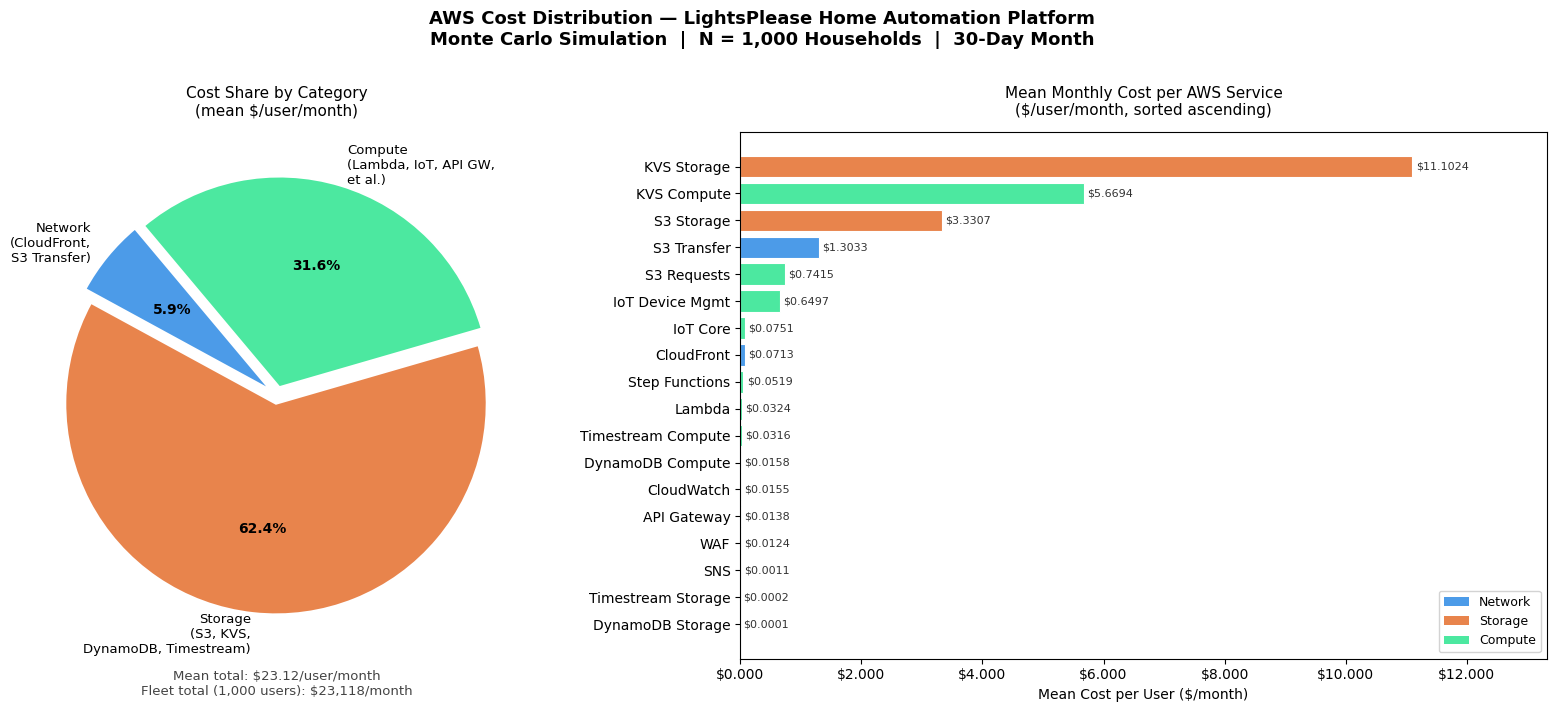

Saved → ../data/cost_distribution.png


In [3]:
# ── Figure 1: Pie + horizontal bar — cost by category and service ─────────────

PALETTE = {
    "Network": "#4C9BE8",
    "Storage": "#E8844C",
    "Compute": "#4CE8A0",
}

# Category means (mean $/user/month across all 1 K simulations)
cat_means = {
    "Network\n(CloudFront,\nS3 Transfer)": cost_network.mean(),
    "Storage\n(S3, KVS,\nDynamoDB, Timestream)": cost_storage.mean(),
    "Compute\n(Lambda, IoT, API GW,\net al.)": cost_compute.mean(),
}

# Per-service mean costs and their category tag
services = {
    # label                         : (mean_cost,   category)
    "CloudFront": (cost_cf.mean(), "Network"),
    "S3 Transfer": (cost_s3_x.mean(), "Network"),
    "KVS Storage": (cost_kvs_s.mean(), "Storage"),
    "KVS Compute": (cost_kvs_c.mean(), "Compute"),
    "S3 Storage": (cost_s3_s.mean(), "Storage"),
    "S3 Requests": (cost_s3_r.mean(), "Compute"),
    "DynamoDB Storage": (cost_dynamo_s.mean(), "Storage"),
    "DynamoDB Compute": (cost_dynamo_c.mean(), "Compute"),
    "Timestream Storage": (cost_ts_s.mean(), "Storage"),
    "Timestream Compute": (cost_ts_c.mean(), "Compute"),
    "IoT Core": (cost_iot.mean(), "Compute"),
    "IoT Device Mgmt": (cost_iot_dm.mean(), "Compute"),
    "Lambda": (cost_lambda.mean(), "Compute"),
    "Step Functions": (cost_sfn.mean(), "Compute"),
    "API Gateway": (cost_apigw.mean(), "Compute"),
    "WAF": (cost_waf.mean(), "Compute"),
    "SNS": (cost_sns.mean(), "Compute"),
    "CloudWatch": (cost_cw.mean(), "Compute"),
}

# Sort bars by cost ascending (so largest is at top of horizontal bar)
svc_labels = list(services.keys())
svc_vals = [v for v, _ in services.values()]
svc_colors = [PALETTE[c] for _, c in services.values()]
sorted_idx = np.argsort(svc_vals)
svc_labels = [svc_labels[i] for i in sorted_idx]
svc_vals = [svc_vals[i] for i in sorted_idx]
svc_colors = [svc_colors[i] for i in sorted_idx]

fig, (ax_pie, ax_bar) = plt.subplots(
    1, 2, figsize=(16, 7), gridspec_kw={"width_ratios": [1, 1.4]}
)
fig.suptitle(
    "AWS Cost Distribution — LightsPlease Home Automation Platform\n"
    "Monte Carlo Simulation  |  N = 1,000 Households  |  30-Day Month",
    fontsize=13,
    fontweight="bold",
    y=1.01,
)

# ── Left: pie chart ───────────────────────────────────────────────────────────
wedges, texts, autotexts = ax_pie.pie(
    list(cat_means.values()),
    labels=list(cat_means.keys()),
    autopct="%1.1f%%",
    colors=list(PALETTE.values()),
    explode=[0.04] * 3,
    startangle=130,
    wedgeprops={"linewidth": 1.5, "edgecolor": "white"},
    textprops={"fontsize": 9.5},
)
for at in autotexts:
    at.set_fontsize(10)
    at.set_fontweight("bold")
ax_pie.set_title("Cost Share by Category\n(mean $/user/month)", fontsize=11, pad=12)

total_mean = cost_total.mean()
ax_pie.text(
    0,
    -1.42,
    f"Mean total: ${total_mean:.2f}/user/month\n"
    f"Fleet total ({N:,} users): ${cost_total.sum():,.0f}/month",
    ha="center",
    fontsize=9.5,
    color="#444",
)

# ── Right: horizontal bar chart ───────────────────────────────────────────────
bars = ax_bar.barh(
    svc_labels, svc_vals, color=svc_colors, edgecolor="white", linewidth=0.8
)

# Annotate bar values
for bar, val in zip(bars, svc_vals):
    ax_bar.text(
        bar.get_width() + max(svc_vals) * 0.005,
        bar.get_y() + bar.get_height() / 2,
        f"${val:.4f}",
        va="center",
        fontsize=8,
        color="#333",
    )

ax_bar.set_xlabel("Mean Cost per User ($/month)", fontsize=10)
ax_bar.set_title(
    "Mean Monthly Cost per AWS Service\n($/user/month, sorted ascending)",
    fontsize=11,
    pad=12,
)
ax_bar.xaxis.set_major_formatter(mticker.FormatStrFormatter("$%.3f"))
ax_bar.set_xlim(right=max(svc_vals) * 1.20)

legend_handles = [Patch(facecolor=PALETTE[c], label=c) for c in PALETTE]
ax_bar.legend(handles=legend_handles, loc="lower right", fontsize=9, framealpha=0.85)

plt.tight_layout()
chart_path = "../data/cost_distribution.png"
plt.savefig(chart_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {chart_path}")